In [1]:
import pandas as pd
df = pd.read_csv("./boston_housing.csv")
print(df.head())
df.head().to_html("./example2_1.html")

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [2]:
print(df.describe())      
df.describe().to_html("./example2_2.html")

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677082   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

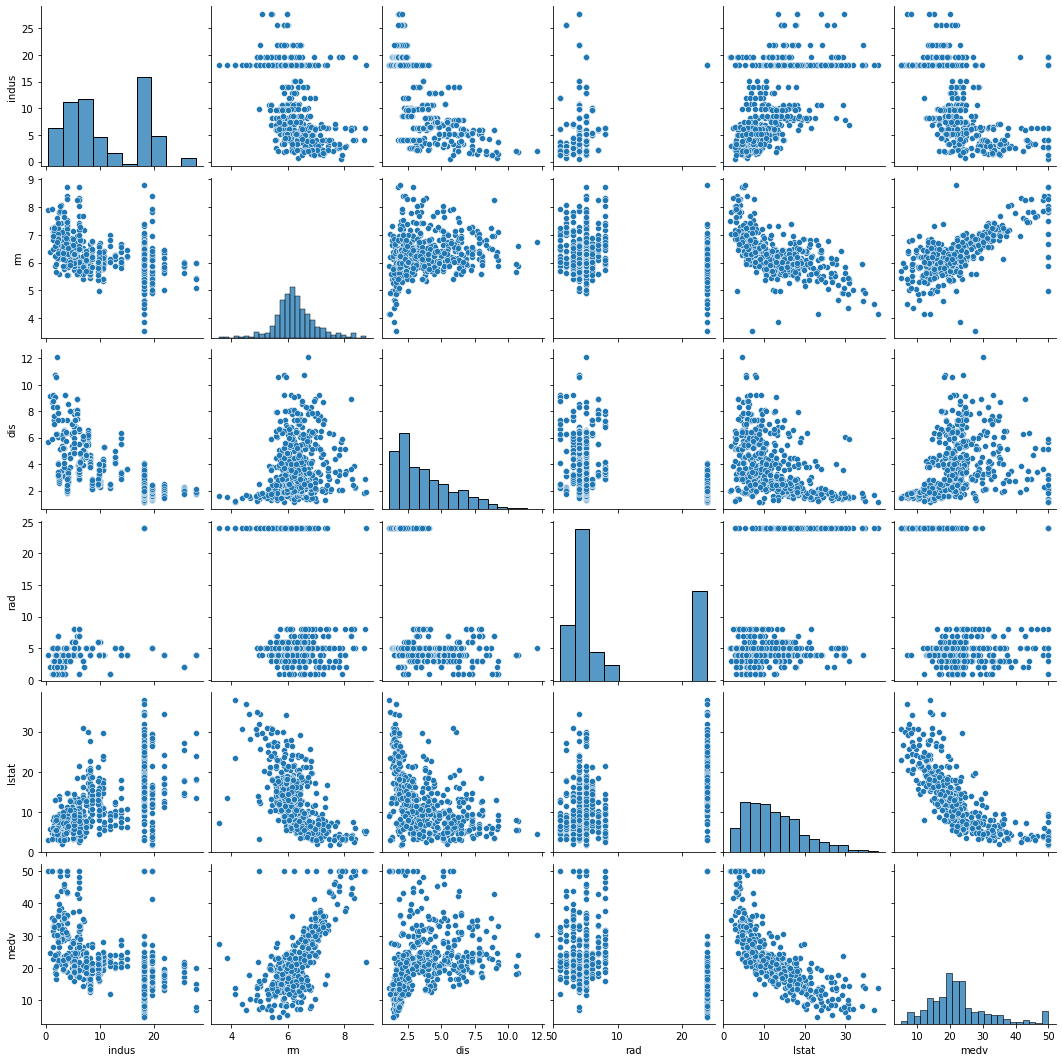

In [3]:
import seaborn as sns
df2=df.drop(["tax","b","nox","chas","crim","ptratio","age","zn"],axis=1)
sns.pairplot(df2)

In [4]:
#載入numpy函式庫(套件)
import numpy as np   
seed=5811
np.random.seed(seed)
df = pd.read_csv("./boston_housing.csv")
dataset = df.values
np.random.shuffle(dataset)

In [5]:
print("#2-4-2 分割資料集")
#分割成特徵資料和標籤資料
#取0-13的欄位資料，共13個欄位的值(輸入資料)
X = dataset[:, 0:13] 
#取編號為13的欄位資料: 第14個欄位的值(輸出資料；自住房屋的中位數價格) 
Y = dataset[:, 13]  

#2-4-2 分割資料集


In [6]:
#特徵標準化
X -= X.mean(axis=0)
X /= X.std(axis=0)

#分割訓練和測試資料集
#訓練資料前404筆
X_train, Y_train = X[:404], Y[:404]     
#測試資料後102筆
X_test, Y_test = X[404:], Y[404:]  

In [7]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape 

((404, 13), (102, 13), (404,), (102,))

In [8]:
def build_model():
    model = Sequential()
    model.add(Dense(32, input_shape=(X_train.shape[1],), activation="relu"))
    model.add(Dense(1))
    model.compile(loss="mse", optimizer="adam",  metrics=["mae"])
    return model


In [9]:
def build_deep_model():
    model = Sequential()
    model.add(Dense(32,input_shape=(X_train.shape[1],), activation="relu"))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))
    model.compile(loss="mse", optimizer="adam",   metrics=["mae"])
    return model


In [10]:
k = 4
nb_val_samples = len(X_train) // k
nb_epochs = 80
mse_scores = []
mae_scores = []
print(nb_val_samples)

101


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

for i in range(k):
    print("Processing Fold #" + str(i))
    X_val = X_train[i*nb_val_samples: (i+1)*nb_val_samples]
    Y_val = Y_train[i*nb_val_samples: (i+1)*nb_val_samples]
    X_train_p = np.concatenate(
            [X_train[:i*nb_val_samples],
            X_train[(i+1)*nb_val_samples:]], axis=0)
    Y_train_p = np.concatenate(
            [Y_train[:i*nb_val_samples],
            Y_train[(i+1)*nb_val_samples:]], axis=0)
    model = build_model() #or model = build_deep_model() 
    model.fit(X_train_p, Y_train_p,  
              epochs=nb_epochs, batch_size=16,  
              verbose=0)
    mse, mae = model.evaluate(X_val, Y_val)
    mse_scores.append(mse)
    mae_scores.append(mae)


Processing Fold #0
4/4 [==============================] - 0s 1ms/step - loss: 21.2277 - mae: 3.2641
Processing Fold #1
4/4 [==============================] - 0s 1ms/step - loss: 16.7296 - mae: 3.1641
Processing Fold #2
4/4 [==============================] - 0s 899us/step - loss: 27.5781 - mae: 3.6865
Processing Fold #3
4/4 [==============================] - 0s 2ms/step - loss: 17.3883 - mae: 3.1313


In [12]:
print("MSE_val: ", np.mean(mse_scores))
print("MAE_val: ", np.mean(mae_scores))
# 使用測試資料評估模型
mse, mae = model.evaluate(X_test, Y_test)    
print("MSE_test: ", mse)
print("MAE_test: ", mae)


MSE_val:  20.730931758880615
MAE_val:  3.311507999897003
4/4 [==============================] - 0s 1ms/step - loss: 17.8315 - mae: 2.8835
MSE_test:  17.83152198791504
MAE_test:  2.883462905883789


In [13]:
print("#3-5 儲存模型")
#方法一：分開儲存模型結構與權重
json_str = model.to_json()
with open("example2_model.config", "w") as text_file:
     text_file.write(json_str)
model.save_weights("example2_model.weight")

#3-5 儲存模型


In [14]:
model.save("example_2.h5")

In [16]:
#模型呼叫  方法一： 
from tensorflow.keras.models import model_from_json
model = Sequential()
with open("example2_model.config", "r") as text_file:
    json_str = text_file.read()
model = model_from_json(json_str)
model.load_weights("example2_model.weight", by_name=False)

In [17]:
#模型呼叫  方法二： 
#from keras.models import load_model
from tensorflow.keras.models import load_model
model = Sequential()
model = load_model("example_2.h5")

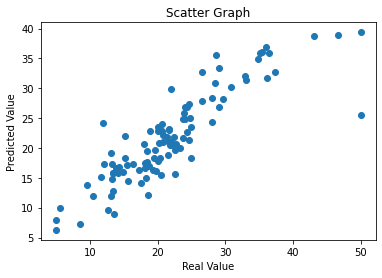

In [18]:
import matplotlib.pyplot as plt   #載入繪圖功能
model.compile(loss="mse", optimizer="adam",  
                  metrics=["mae"])    #編譯模型
Y_pred=model.predict(X_test) #預測
plt.title("Scatter Graph")          
plt.scatter(Y_test, Y_pred)
plt.xlabel("Real Value")
plt.ylabel("Predicted Value")
plt.show()


In [19]:
for i in range(len(Y_test)):
    print(Y_test[i], Y_pred[i][0])

14.1 15.732799
25.0 18.267633
35.1 35.846436
22.0 20.997753
24.4 22.695719
21.7 20.98955
19.8 16.06196
13.5 8.922922
20.7 22.874708
23.7 21.642683
30.8 30.24995
13.4 15.749505
28.1 24.365362
33.1 31.401472
20.5 15.488821
20.3 18.303053
18.4 17.654213
18.9 22.825731
13.3 14.785345
5.0 7.990245
17.2 16.301857
21.7 23.089666
24.8 25.008701
25.0 23.575176
21.9 20.491072
26.6 32.72491
24.4 26.897083
35.4 36.047974
34.9 34.81715
36.5 35.949287
17.5 14.16853
22.4 21.87819
24.1 26.855734
21.4 21.774767
18.4 19.55375
11.9 24.147932
20.1 23.553267
18.3 14.89686
43.1 38.698887
11.7 15.184765
13.4 15.85199
5.0 6.27276
23.8 24.894388
22.0 29.905825
28.0 28.316145
18.7 17.015612
19.3 16.291185
29.1 26.805746
5.6 9.867769
50.0 25.521605
21.7 22.975813
23.9 25.85362
19.6 19.708271
13.1 11.922427
12.1 17.231022
15.6 14.535653
22.6 19.628109
16.4 17.375307
24.7 21.401812
22.5 15.715548
13.4 12.73128
22.7 20.717207
24.1 24.76482
13.3 17.348013
29.6 28.164715
18.2 17.548628
20.6 24.067266
36.0 36.91845
20